# Week 3 — Advanced Models & Optimization
1. Train KNN, Ridge Regression
2. Hyperparameter Tuning
3. Compare Models
4. Select Best Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#333',
    'grid.alpha': 0.4
})

# Load and preprocess
df = pd.read_csv('data/delivery_data.csv')

df['congestion'].fillna(df.groupby(['zone','hour'])['congestion'].transform('median'), inplace=True)
df['congestion'].fillna(df['congestion'].median(), inplace=True)
df['distance_km'].fillna(df['distance_km'].median(), inplace=True)
df['delivery_time_min'].fillna(df['delivery_time_min'].median(), inplace=True)

df = df.fillna(df.median(numeric_only=True))
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df['is_peak_hour'] = df['hour'].apply(lambda h: 1 if (8<=h<=10 or 17<=h<=20) else 0)
df['is_weekend'] = df['day_of_week'].apply(lambda d: 1 if d>=5 else 0)

le = LabelEncoder()
df['vehicle_enc'] = le.fit_transform(df['vehicle_type'])
df['weather_enc'] = le.fit_transform(df['weather'])
df['zone_enc'] = le.fit_transform(df['zone'])

FEATURES = ['distance_km', 'congestion', 'hour', 'day_of_week', 'num_stops',
            'is_peak_hour', 'is_weekend', 'vehicle_enc', 'weather_enc', 'zone_enc']
TARGET = 'delivery_time_min'

X = df[FEATURES]
y = df[TARGET]

if X.isnull().values.any():
    X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [2]:
models_config = {
    'KNN Regression': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance']
        }
    },
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'params': {
            'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    }
}

results = []
best_models = {}

for name, config in models_config.items():
    print(f"Searching for {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_s)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Best Params': str(grid.best_params_)
    })
    best_models[name] = best_model
    print(f"  Best R2: {r2:.4f}")

results_df = pd.DataFrame(results)
display(results_df)

Searching for KNN Regression...


  Best R2: 0.8233
Searching for Ridge Regression...
  Best R2: 0.9108


,Model,MAE,RMSE,R2,Best Params
0,KNN Regression,11.538707,15.241200,0.823334,"{'n_neighbors': 7, 'weights': 'distance'}"
1,Ridge Regression,7.711619,10.828434,0.910824,{'alpha': 1.0}


In [3]:
best_row = results_df.loc[results_df['R2'].idxmax()]
best_model_name = best_row['Model']
print(f"Best Model Selected: {best_model_name}")

os.makedirs('models', exist_ok=True)
with open('models/best_delivery_model.pkl', 'wb') as f:
    pickle.dump(best_models[best_model_name], f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Saved {best_model_name} and scaler to models/")

Best Model Selected: Ridge Regression
Saved Ridge Regression and scaler to models/


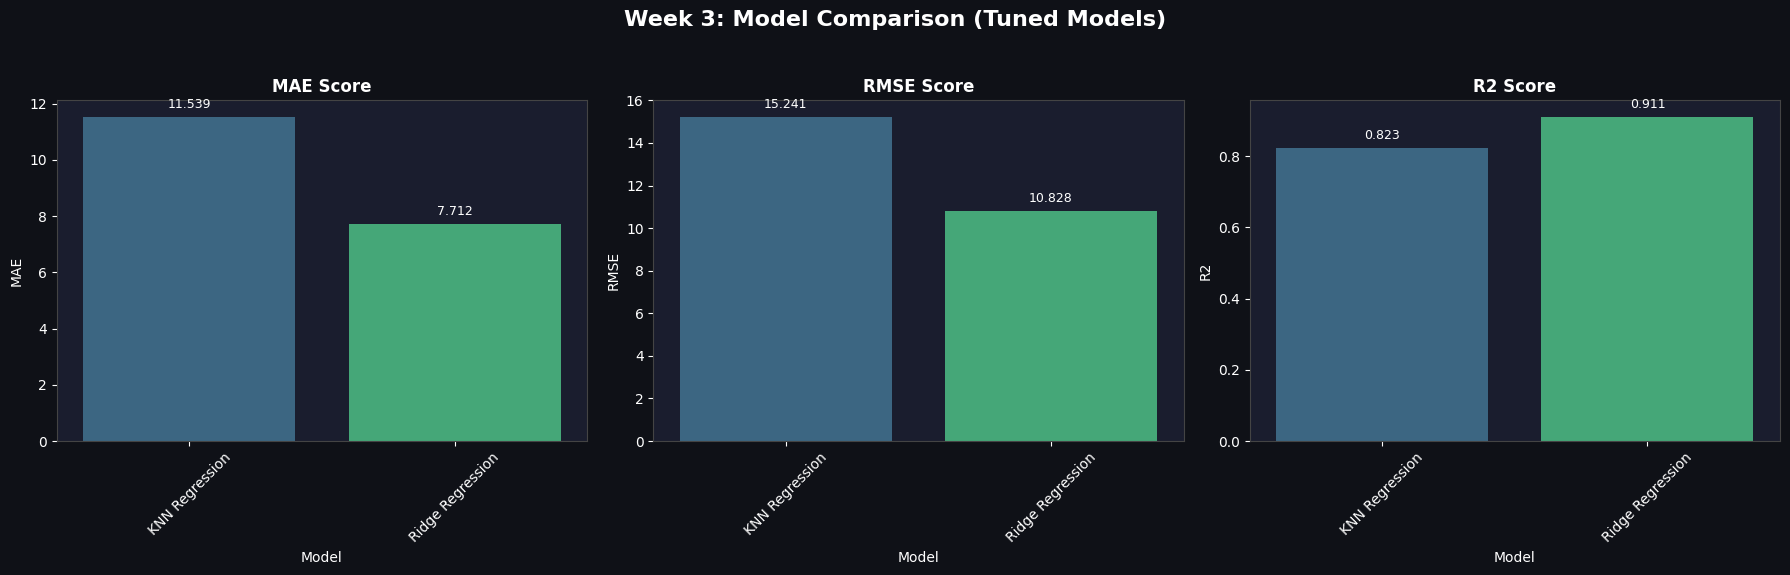

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Week 3: Model Comparison (Tuned Models)', fontsize=16, fontweight='bold')

metrics = ['MAE', 'RMSE', 'R2']

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Score', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 9), 
                         textcoords='offset points', fontsize=9, color='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()